<a href="https://colab.research.google.com/github/dionysus-laughed/school_cs4410/blob/main/summers_hw4_cs4410.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import confusion_matrix, classification_report

In [2]:
breast_cancer = load_breast_cancer()

In [3]:
print("Data shape:", breast_cancer.data.shape)
print("Target shape:", breast_cancer.target.shape)

Data shape: (569, 30)
Target shape: (569,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    breast_cancer.data,
    breast_cancer.target,
    test_size=0.25,
    random_state=11
)

In [5]:
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (426, 30)
Testing set size: (143, 30)


In [6]:
nb = GaussianNB()

In [7]:
nb.fit(X_train, y_train)

GaussianNB()

In [8]:
predicted = nb.predict(X_test)

In [9]:
print("Model accuracy:", nb.score(X_test, y_test))

Model accuracy: 0.951048951048951


In [10]:
cm = confusion_matrix(y_test, predicted)
cm

array([[44,  6],
       [ 1, 92]])

In [11]:
print(classification_report(y_test, predicted, target_names=breast_cancer.target_names))

              precision    recall  f1-score   support

   malignant       0.98      0.88      0.93        50
      benign       0.94      0.99      0.96        93

    accuracy                           0.95       143
   macro avg       0.96      0.93      0.94       143
weighted avg       0.95      0.95      0.95       143



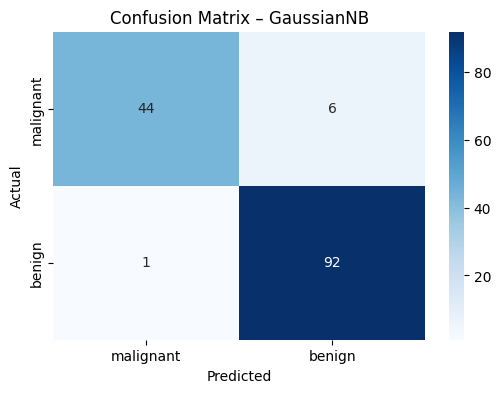

In [12]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=breast_cancer.target_names,
            yticklabels=breast_cancer.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – GaussianNB")
plt.show()

In [13]:
kfold = KFold(n_splits=10, random_state=11, shuffle=True)

scores = cross_val_score(
    estimator=nb,
    X=breast_cancer.data,
    y=breast_cancer.target,
    cv=kfold
)

print("Cross-validation scores:", scores)
print("Mean CV accuracy:", scores.mean())

Cross-validation scores: [0.96491228 0.9122807  0.94736842 0.89473684 0.96491228 0.94736842
 0.96491228 0.89473684 0.96491228 0.92857143]
Mean CV accuracy: 0.9384711779448622


In [14]:
estimators = {
    'GaussianNB': nb,
    'KNeighborsClassifier': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(
        solver='lbfgs', multi_class='ovr', max_iter=10000
    ),
    'SVC': SVC(gamma='scale')
}

In [15]:
for name, estimator in estimators.items():
    scores = cross_val_score(
        estimator=estimator,
        X=breast_cancer.data,
        y=breast_cancer.target,
        cv=kfold
    )
    print(f"{name}: Mean accuracy = {scores.mean():.4f}")

GaussianNB: Mean accuracy = 0.9385
KNeighborsClassifier: Mean accuracy = 0.9279


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was depre

LogisticRegression: Mean accuracy = 0.9508
SVC: Mean accuracy = 0.9192
